In [2]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold


from new_pipeline import build_pipeline
from pipe_sem_feature import build_pipe

target_col = "churned"
train_size = 0.85
val_size = 0.20
random_state = 42

In [3]:
import mlflow

# Substitua pelo ARN do seu MLflow App criado no console do SageMaker
tracking_server_arn = "arn:aws:sagemaker:us-east-2:906513713169:mlflow-app/app-G677ZQHBYJVJ"

# Configura o MLflow para enviar os logs para o SageMaker
mlflow.set_tracking_uri(tracking_server_arn)

print(f"Conectado ao Tracking Server: {mlflow.get_tracking_uri()}")

Conectado ao Tracking Server: arn:aws:sagemaker:us-east-2:906513713169:mlflow-app/app-G677ZQHBYJVJ


In [6]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

# 1. Carregar os modelos recuperados do MLflow
print("Carregando modelos...")
artefato_1 = joblib.load("xgb.pkl")
artefato_2 = joblib.load("gbmv2.pkl")

# Função auxiliar à prova de falhas para extrair as predições
def prever_com_artefato(artefato, X):
    if isinstance(artefato, dict):
        # Se for o formato dicionário (Pipeline separado do modelo)
        X_transf = artefato['pipe_cat'].transform(X)
        return artefato['model'].predict_proba(X_transf)[:, 1]
    else:
        # Se for um Pipeline completo do Scikit-Learn
        return artefato.predict_proba(X)[:, 1]

# 2. Avaliar os modelos individualmente na VALIDAÇÃO
print("Gerando predições de validação...")
preds_val_1 = prever_com_artefato(artefato_1, X_val)
preds_val_2 = prever_com_artefato(artefato_2, X_val)

auc_1 = roc_auc_score(y_val, preds_val_1)
auc_2 = roc_auc_score(y_val, preds_val_2)

print(f"✅ AUC Modelo 1 (Validação): {auc_1:.5f}")
print(f"✅ AUC Modelo 2 (Validação): {auc_2:.5f}")

# 3. Testar o "Mega Blend" Exponencial na Validação
print("\nCalculando o Power Rank Blend na Validação...")
potencia = 2 # O elevador exponencial que empurra os casos de alto risco pro topo

# A mágica de normalizar por Rank (Percentil)
r1_val = pd.Series(preds_val_1).rank(pct=True)
r2_val = pd.Series(preds_val_2).rank(pct=True)

# Pesos dinâmicos baseados em quem foi melhor no passo 2
# Dica: Se o AUC do Modelo 1 for muito maior, mude para w1=0.7 e w2=0.3
w1 = 0.5 
w2 = 0.5 

preds_blend_val = ((r1_val**potencia)*w1 + (r2_val**potencia)*w2)**(1/potencia)
auc_blend = roc_auc_score(y_val, preds_blend_val)

print(f"🚀 AUC do BLEND (Validação): {auc_blend:.5f}")

Carregando modelos...


c:\Users\rafag\OneDrive\Documents\Vini\POLI JUNIOR\PRT\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\rafag\OneDrive\Documents\Vini\POLI JUNIOR\PRT\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\rafag\OneDrive\Documents\Vini\POLI JUNIOR\PRT\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to

Gerando predições de validação...
✅ AUC Modelo 1 (Validação): 0.82048
✅ AUC Modelo 2 (Validação): 0.82804

Calculando o Power Rank Blend na Validação...
🚀 AUC do BLEND (Validação): 0.82509


In [9]:
preds_modelo_2 = prever_com_artefato(artefato_2, X_test)

# Criar submissão
submissao = pd.DataFrame({
    "Id": df_teste_original["id_cliente"],
    "churn_prob": preds_modelo_2
})

# Salvar CSV
submissao.to_csv("SUBMISSAO_MODELO_2.csv", index=False)

print(submissao.head())
print("Arquivo SUBMISSAO_MODELO_2.csv gerado com sucesso!")

             Id  churn_prob
0  221300000002    0.021143
1  221300000020    0.034501
2  221300000097    0.024075
3  221300000148    0.066893
4  221300000166    0.089424
Arquivo SUBMISSAO_MODELO_2.csv gerado com sucesso!


In [14]:
import pandas as pd

# Carregue suas submissões
sub1 = pd.read_csv("submissao_rf.csv")
sub2 = pd.read_csv("lgb.csv")

# Blend simples (Média das probabilidades)
sub_final = sub1.copy()
sub_final['churn_prob'] = (sub1['churn_prob'] + sub2['churn_prob']) / 2

# Rank Averaging (Mais poderoso para AUC-ROC!)
# Ao invés do valor bruto, usamos o rank (posição na fila), o que ignora calibrações bizarras
sub_final['churn_prob'] = (sub1['churn_prob'].rank() + sub2['churn_prob'].rank()) / 2

sub_final.to_csv("submissao_salvadora.csv", index=False)

In [3]:
# PEGA DADOS DE TREINO

data_dir = f"bases_tratadas"


df_cadastros = pd.read_csv(f'{data_dir}/cadastro_tratado.csv')
df_sinistros = pd.read_csv(f'{data_dir}/sinistros_tratado.csv')
df_mkt = pd.read_csv(f'{data_dir}/engajamento_marketing_tratado.csv')
df_contratos = pd.read_csv(f'{data_dir}/contratos_apolices_tratado.csv')
df_churn = pd.read_csv(f'{data_dir}/churn_.csv')

for df in [df_cadastros, df_sinistros, df_churn, df_contratos, df_mkt]:
    df['id_cliente'] = df['id_cliente'].astype(str).str.strip()

df_train = (
        df_churn
        .merge(df_contratos, on='id_cliente', how='left')
        .merge(df_mkt,       on='id_cliente', how='left')
        .merge(df_cadastros, on='id_cliente', how='left')
        .merge(df_sinistros, on='id_cliente', how='left')
        .copy()
    )


PISOS_LOGICOS = {
    # 📄 Contratos
    "valor_premio_anual": 300.0,       # Prêmio anual de R$ 0,01 é impossível
    "valor_cobertura_total": 10000.0,  # Cobertura incompatível com valor de um veículo
    "franquia_media": 300.0,           # Franquia mínima razoável
    
    # 👤 Cadastro
    "renda_anual": 3000.0,             # Renda incompatível com posse de veículo/seguro
    "tempo_residencia_anos": 0,        # Impede anos negativos inseridos por erro no BD
    
    # 🚗 Marketing / Engajamento
    "km_anual_estimado": 100.0         # Evita KM zero para veículos não-colecionáveis em uso
}

# Varredura corretiva
for col, piso in PISOS_LOGICOS.items():
    if col in df_train.columns:
        # Transforma tudo que for estritamente menor que o piso lógico em NaN
        mascara_incoerente = df_train[col] < piso
        df_train.loc[mascara_incoerente, col] = np.nan

train_df, val_df = train_test_split(
    df_train,
    test_size=(val_size),
    stratify=df_train[target_col],
    random_state=random_state,
    )


X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_val   = val_df.drop(columns=[target_col])
y_val   = val_df[target_col]

In [ ]:
# PEGA DADOS DE TESTE - KAGGLE
data_dir = f"teste_limpo"


df_cadastros   = pd.read_csv(f'{data_dir}/cadastro_tratado.csv')
df_sinistros   = pd.read_csv(f'{data_dir}/sinistros_tratado.csv')
df_mkt         = pd.read_csv(f'{data_dir}/engajamento_marketing_tratado.csv')
df_contratos   = pd.read_csv(f'{data_dir}/contratos_apolices_tratado.csv')

for df in [df_cadastros, df_sinistros, df_contratos, df_mkt]:
    if 'id_cliente' in df.columns:
        df['id_cliente'] = df['id_cliente'].astype(str).str.strip()

df = (
        df_contratos
        .merge(df_mkt,       on='id_cliente', how='outer')
        .merge(df_cadastros, on='id_cliente', how='outer')
        .merge(df_sinistros, on='id_cliente', how='outer')
        .copy()
    )

# Varredura corretiva
for col, piso in PISOS_LOGICOS.items():
    if col in df.columns:
        # Transforma tudo que for estritamente menor que o piso lógico em NaN
        mascara_incoerente = df[col] < piso
        df.loc[mascara_incoerente, col] = np.nan

df_teste_original = df.copy()
X_test = df.copy()

In [5]:
pipe_sf = build_pipeline()["pipeline"]

X_train_final = pipe_sf.fit_transform(X_train, y_train)
X_val_final = pipe_sf.transform(X_val)

c:\Users\rafag\OneDrive\Documents\Vini\POLI JUNIOR\PRT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TREINANDO: LightGBM
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     17581
           1       0.56      0.16      0.25      2419

    accuracy                           0.88     20000
   macro avg       0.73      0.57      0.59     20000
weighted avg       0.85      0.88      0.85     20000

AUC Validação: 0.8247
Gap AUC: 0.0104
TREINANDO: XGBoost
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     17581
           1       0.56      0.16      0.25      2419

    accuracy                           0.88     20000
   macro avg       0.73      0.57      0.59     20000
weighted avg       0.85      0.88      0.85     20000

AUC Validação: 0.8251
Gap AUC: 0.0188
TREINANDO: Regressao_Logistica


c:\Users\rafag\OneDrive\Documents\Vini\POLI JUNIOR\PRT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.88      1.00      0.94     17581
           1       0.58      0.04      0.08      2419

    accuracy                           0.88     20000
   macro avg       0.73      0.52      0.51     20000
weighted avg       0.85      0.88      0.83     20000

AUC Validação: 0.7857
Gap AUC: -0.0058

RESULTADO FINAL


,AUC_Treino,AUC_Validacao,Accuracy,Precision,Recall,F1,Gap_AUC,TN,FP,FN,TP
XGBoost,0.84389,0.825129,0.88335,0.56196,0.161224,0.250562,0.018761,17277,304,2029,390
LightGBM,0.835096,0.824669,0.88295,0.556851,0.157916,0.246055,0.010427,17277,304,2037,382
Regressao_Logistica,0.779817,0.785659,0.8804,0.577143,0.041753,0.077872,-0.005842,17507,74,2318,101


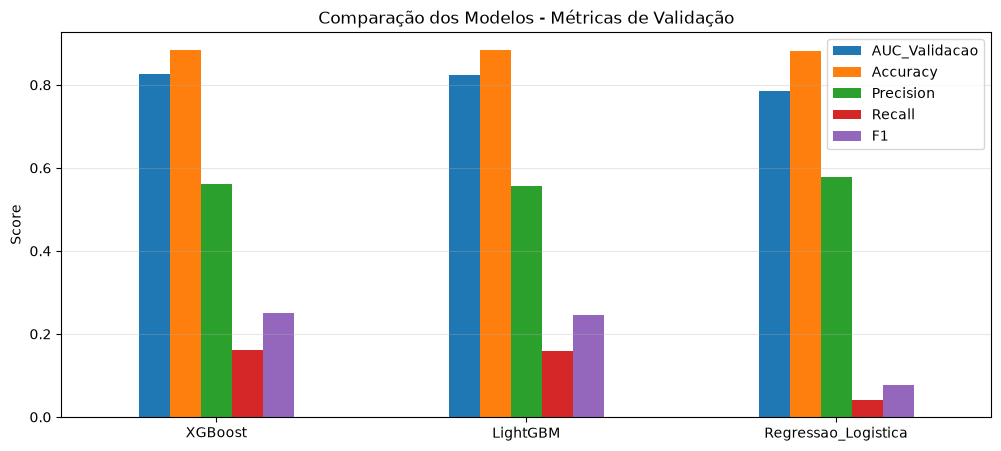

In [6]:
import pandas as pd
import numpy as np

import mlflow
import mlflow.sklearn

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# DEFINIÇÃO DOS MODELOS
# ============================================================

modelos = {

    "LightGBM": LGBMClassifier(
        boosting_type="gbdt",
        num_leaves=15,
        learning_rate=0.01,
        n_estimators=500,
        subsample=0.8,
        colsample_bytree=0.7,
        random_state=42,
        force_col_wise=True,
        verbosity=-1,
        n_jobs=-1
    ),


    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        learning_rate=0.01,
        n_estimators=500,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.7,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),


    "Regressao_Logistica": LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}


# ============================================================
# CONFIGURAÇÃO MLFLOW
# ============================================================

# ============================================================
# TREINAMENTO E AVALIAÇÃO
# ============================================================

resultados = {}


for nome, modelo in modelos.items():

    print("="*60)
    print(f"TREINANDO: {nome}")
    print("="*60)


        # -------------------------
        # TREINO
        # -------------------------

    modelo.fit(
            X_train_final,
            y_train
        )


        # -------------------------
        # TREINO - MÉTRICAS
        # -------------------------

    prob_train = modelo.predict_proba(
            X_train_final
        )[:,1]

    pred_train = (
            prob_train >= 0.5
        ).astype(int)


    auc_train = roc_auc_score(
            y_train,
            prob_train
        )

    acc_train = accuracy_score(
            y_train,
            pred_train
        )


        # -------------------------
        # VALIDAÇÃO
        # -------------------------

    prob_val = modelo.predict_proba(
            X_val_final
        )[:,1]

    pred_val = (
            prob_val >= 0.5
        ).astype(int)



    auc_val = roc_auc_score(
            y_val,
            prob_val
        )

    acc_val = accuracy_score(
            y_val,
            pred_val
        )

    precision = precision_score(
            y_val,
            pred_val
        )

    recall = recall_score(
            y_val,
            pred_val
        )

    f1 = f1_score(
            y_val,
            pred_val
        )


        # -------------------------
        # MATRIZ CONFUSÃO
        # -------------------------

    tn, fp, fn, tp = confusion_matrix(
            y_val,
            pred_val
        ).ravel()



        # -------------------------
        # GAP OVERFIT
        # -------------------------

    gap_auc = auc_train - auc_val



        # -------------------------
        # RESULTADOS
        # -------------------------

    resultados[nome] = {

            "modelo": modelo,

            "AUC_Treino": auc_train,

            "AUC_Validacao": auc_val,

            "Accuracy": acc_val,

            "Precision": precision,

            "Recall": recall,

            "F1": f1,

            "Gap_AUC": gap_auc,

            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        }



        # -------------------------
        # LOG MLFLOW
        # -------------------------




        # -------------------------
        # RELATÓRIO
        # -------------------------

    print(
            classification_report(
                y_val,
                pred_val
            )
        )

    print(
            f"AUC Validação: {auc_val:.4f}"
        )

    print(
            f"Gap AUC: {gap_auc:.4f}"
        )



# ============================================================
# TABELA FINAL COMPARATIVA
# ============================================================

df_comparacao = pd.DataFrame(
    resultados
).T


df_comparacao = (
    df_comparacao
    .drop(columns=["modelo"])
    .sort_values(
        "AUC_Validacao",
        ascending=False
    )
)



print("\nRESULTADO FINAL")
display(
    df_comparacao.round(4)
)


# ============================================================
# GRÁFICO COMPARATIVO
# ============================================================

import matplotlib.pyplot as plt


metricas_plot = [
    "AUC_Validacao",
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]


df_comparacao[metricas_plot].plot(
    kind="bar",
    figsize=(12,5)
)

plt.title(
    "Comparação dos Modelos - Métricas de Validação"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [9]:
import pandas as pd

# 1. Carregar o seu teste original limpo e o Megablend
# Assumindo que 'df_test' é o seu dataset de teste preparado (sem a variável target)
# e 'df_train' é o seu treino original preparado (com a variável 'churned')
sub_megablend = pd.read_csv("MEGABLEND_KAGGLE_FINAL.csv") 
df_test_pseudo = df_teste_original.copy()

# 2. Trazer as predições do Megablend temporariamente para o df_test
df_test_pseudo['churn_prob'] = sub_megablend['churn_prob']

# 3. Filtrar os extremos de altíssima confiança (Top 5% e Bottom 5%)
pseudo_churn = df_test_pseudo[df_test_pseudo['churn_prob'] >= 0.95].copy()
pseudo_retido = df_test_pseudo[df_test_pseudo['churn_prob'] <= 0.05].copy()

# 4. A MÁGICA: Criar a variável target com o NOME EXATO que está no treino ('churned')
pseudo_churn['churned'] = 1
pseudo_retido['churned'] = 0

# 5. Dropar a coluna 'churn_prob' para as colunas baterem perfeitamente com o df_train original
pseudo_churn = pseudo_churn.drop(columns=['churn_prob'])
pseudo_retido = pseudo_retido.drop(columns=['churn_prob'])

print(f"Adicionando {len(pseudo_churn)} Churns e {len(pseudo_retido)} Retenções super confiáveis do Teste no Treino!")

# 6. Concatenação Final (Treino Original + Pseudo Labels do Megablend)
# Agora os schemas são idênticos, não vai dar erro!
df_train_mega_enriquecido = pd.concat([df_train, pseudo_churn, pseudo_retido], ignore_index=True)

# 7. (Opcional mas recomendado) Embaralhar o novo dataset para o modelo não ler tudo em ordem
df_train_mega_enriquecido = df_train_mega_enriquecido.sample(frac=1, random_state=42).reset_index(drop=True)

# PRONTO! Agora é só treinar o seu XGBoost/LightGBM ou CatBoost 
# passando X = df_train_mega_enriquecido.drop(columns=['churned']) e y = df_train_mega_enriquecido['churned']

Adicionando 4912 Churns e 4321 Retenções super confiáveis do Teste no Treino!


In [11]:
X_train_rich = df_train_mega_enriquecido.drop(columns="churned")
y_train_rich = df_train_mega_enriquecido["churned"]

In [13]:
X_final = pipe_sf.fit_transform(X_train_rich)

In [18]:
from lightgbm import LGBMClassifier
import lightgbm as lgb

model = LGBMClassifier(
    objective='binary',
    metric='auc',
    learning_rate=0.03,
    max_depth=3,
    num_leaves=7,
    min_child_samples=150,
    colsample_bytree=0.4,
    subsample=0.7,
    reg_alpha=0,
    reg_lambda=20,
    is_unbalance=True,
    n_estimators=1000
)

model.fit(
    X_final,
    y_train_rich,
    eval_set=[(X_val_final, y_val)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

[LightGBM] [Info] Number of positive: 17006, number of negative: 92227
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3886
[LightGBM] [Info] Number of data points in the train set: 109233, number of used features: 77
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.155686 -> initscore=-1.690687
[LightGBM] [Info] Start training from score -1.690687
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.821455
[200]	valid_0's auc: 0.824556
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

,num_leaves,7
,max_depth,3
,learning_rate,0.03
,n_estimators,1000
,objective,'binary'
,min_child_samples,150
,subsample,0.7
,colsample_bytree,0.4
,reg_lambda,20
,metric,'auc'
,is_unbalance,True


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np


rf_seguro = RandomForestClassifier(
    n_estimators=500,
    criterion='gini',
    max_depth=15,             
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    n_jobs=-1,
    class_weight='balanced'
)

sementes = [42, 100, 999]
preds_lista = []

print("Treinando o Enxame de Random Forests...")
for seed in sementes:
    print(f"Treinando semente {seed}...")
    rf_seguro.set_params(random_state=seed)
    
    rf_seguro.fit(X_train_final, y_train) 
    
    pred = rf_seguro.predict_proba(X_test_final)[:, 1]
    preds_lista.append(pred)

pred_final_rf = np.mean(preds_lista, axis=0)

sub_rf = pd.DataFrame({
    "Id": df_teste_original["id_cliente"],
    "churn_prob": pred_final_rf
})
sub_rf.to_csv("RF_Seed_Averaging.csv", index=False)
print("Submissão do RF gerada!")

Treinando o Enxame de Random Forests...
Treinando semente 42...
Treinando semente 100...
Treinando semente 999...
Submissão do RF gerada!


In [21]:
sub_rf = pd.DataFrame({
    "Id": df_teste_original["id_cliente"],
    "churn_prob": pred_final_rf
})
sub_rf.to_csv("RF_Seed_Averaging.csv", index=False)
print("Submissão do RF gerada!")

Submissão do RF gerada!


In [ ]:
import mlflow.sklearn
import pandas as pd

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


peso_minoria = (y_train == 0).sum() / (y_train == 1).sum()

modelos = {
    "LightGBM": LGBMClassifier( n_estimators=886, 
    learning_rate=0.005380513144113074, 
    num_leaves=52, 
    max_depth=7, 
    min_child_samples=94, 
    subsample=0.5469181724885126, 
    colsample_bytree=0.5045681603878812, 
    reg_alpha=1.3479350594392252,
    reg_lambda=2.520480706228077, 
    min_split_gain=0.2255963715835958, 
    random_state=42, n_jobs=-1, verbosity=-1 ),

    "XGBoost": XGBClassifier(
        learning_rate=0.05,
        n_estimators=100,
        max_depth=3,
        subsample=1.0,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=peso_minoria
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=1000,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        max_features = "sqrt",
        min_samples_leaf = 8
    )
}

c:\Users\rafag\OneDrive\Documents\Vini\POLI JUNIOR\PRT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train_final, y_train)
    prob_val = modelo.predict_proba(X_val_final)[:, 1]
    pred_val = (prob_val >= 0.5).astype(int)

        # Métricas
    auc = roc_auc_score(y_val, prob_val)
    acc = accuracy_score(y_val, pred_val)
    prec = precision_score(y_val, pred_val)
    rec = recall_score(y_val, pred_val)
    f1 = f1_score(y_val, pred_val)


    resultados[nome] = {
            "modelo": modelo,
            "auc": auc,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1
        }

        # ====================================================
# RESULTADOS DA VALIDAÇÃO
# ====================================================

resultado_df = (
    pd.DataFrame(resultados)
      .T[["auc", "accuracy", "precision", "recall", "f1"]]
      .sort_values("auc", ascending=False)
)

print("\n================ RESULTADOS ==================")
print(resultado_df)

# ====================================================
# MELHOR MODELO
# ====================================================

melhor_nome = resultado_df.index[0]
melhor_modelo = resultados[melhor_nome]["modelo"]

print(f"\nMelhor modelo: {melhor_nome}")
print(f"AUC = {resultados[melhor_nome]['auc']:.4f}")


================ RESULTADOS ==================
               auc accuracy precision    recall        f1
LightGBM  0.824062   0.8827  0.552217   0.15957  0.247595
XGBoost    0.82272  0.74555  0.289764  0.760645   0.41966

Melhor modelo: LightGBM
AUC = 0.8241


In [9]:
prob_churn_xgb = modelos["LightGBM"].predict_proba(X_test_final)[:, 1]

# Arquivo de Submissão
submissao = pd.DataFrame({
    "Id": df_teste_original["id_cliente"],
    "churn_prob": prob_churn_xgb
})

submissao.to_csv("lgb.csv", index=False)
print("Submissão salva com sucesso!")

Submissão salva com sucesso!
